In [1]:
#Djikastra Algorithm
!pip install networkx matplotlib

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph[current_node].items():
      distance = current_distance + weight
      if distance < distances[neighbor]:
        distances[neighbor] =  distance
        previous[neighbor] = current_node
        heapq.heappushpop(queue, (distance, neighbor))

  return distances, previous


In [3]:
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

In [7]:
def visualize_graph_circular(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight = weight)
      pos = nx.circular_layout(G)
      edge_labels = nx.get_edge_attributes(G, 'weight')

      plt.figure(figsize=(8,6))
      nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows = True)
      nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

      #Garis tebal untuk jalur terpendek
      if path and len(path)>1:
        path_edges = list(zip(path, path[1:1]))
        nx.draw_networkx_edges(G, pos, edgelist = path_edges, edge_color='red', width=3)

      plt.title('Visualisasi Graf (Circular Layout) dan Jalur Terpendek')
      plt.axis('off')
      plt.show()

Jarak dari A ke Z: inf
Jalur: Z


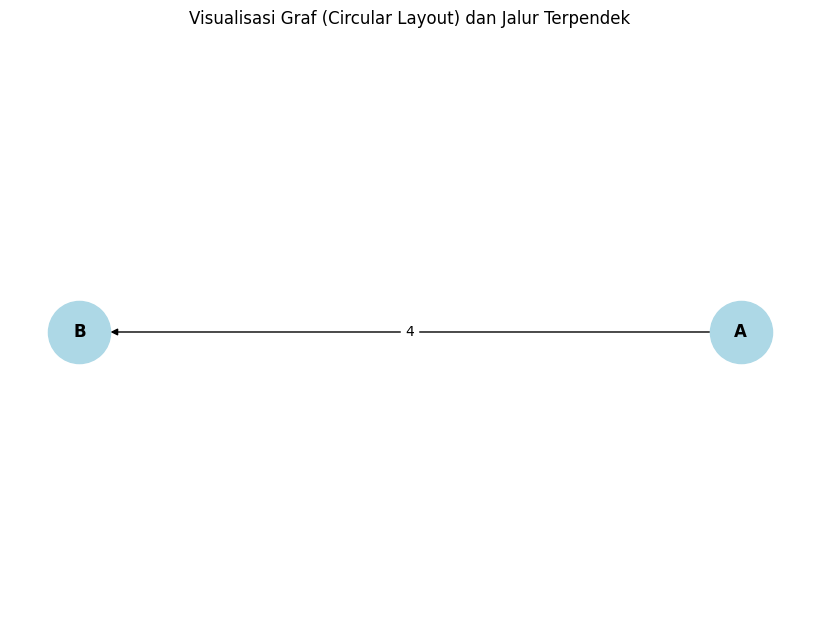

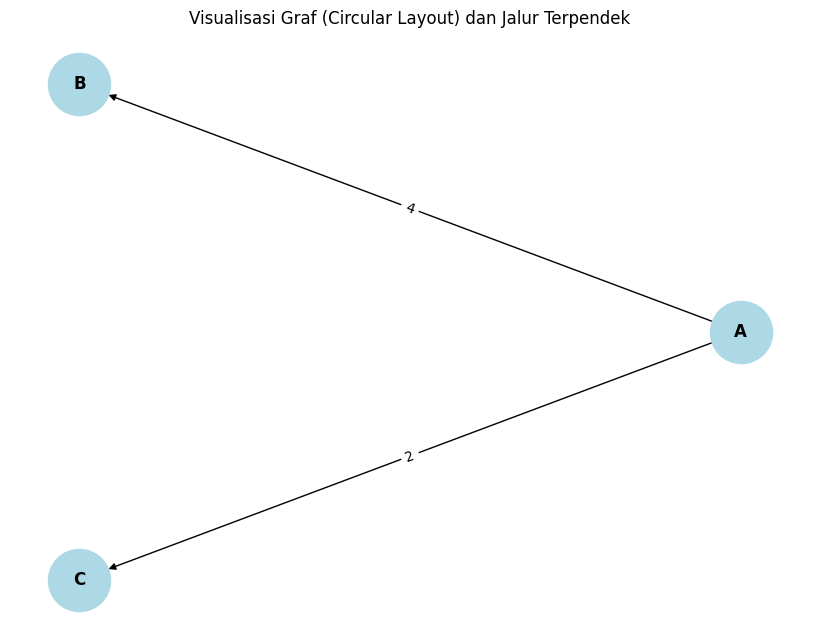

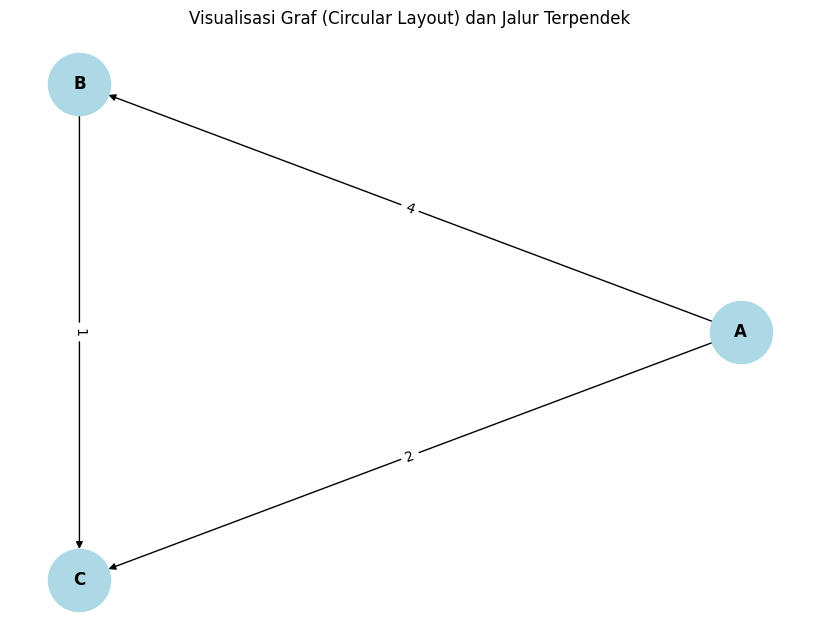

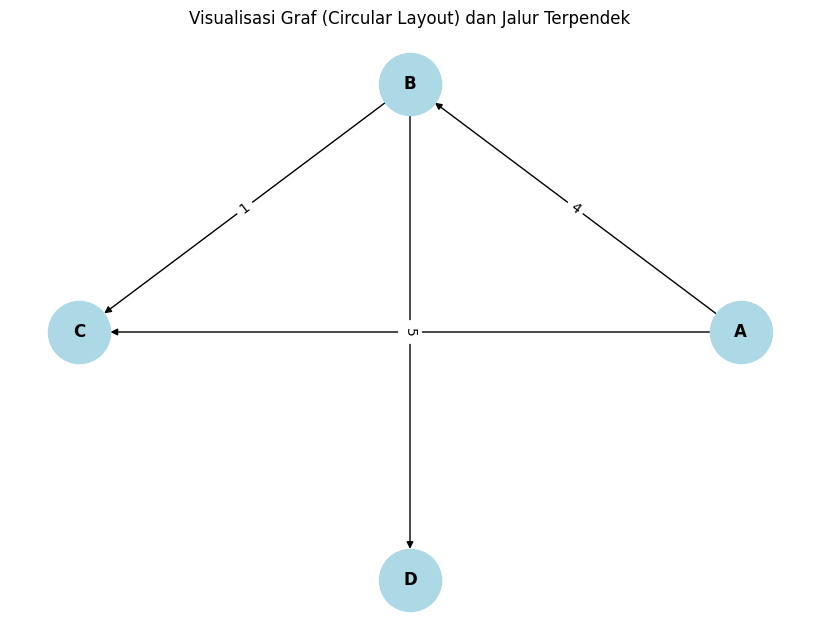

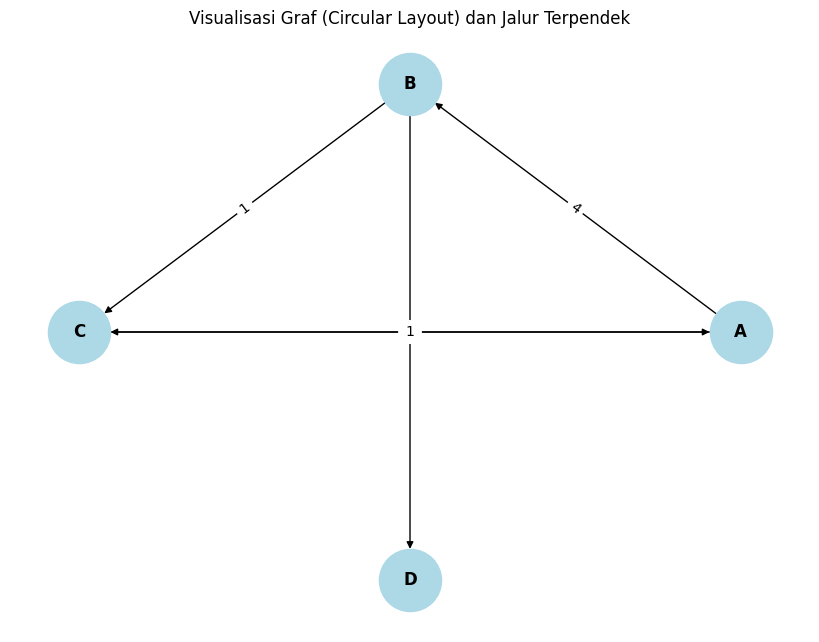

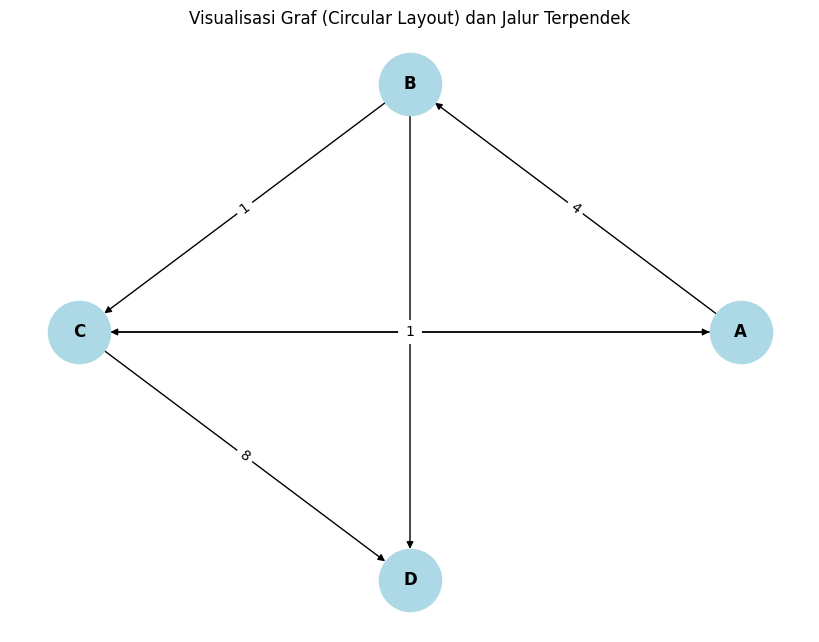

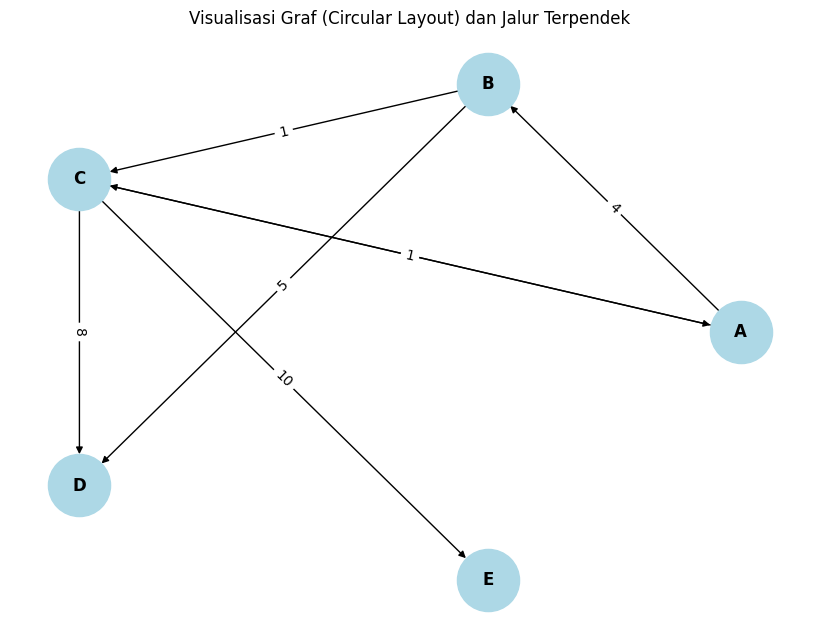

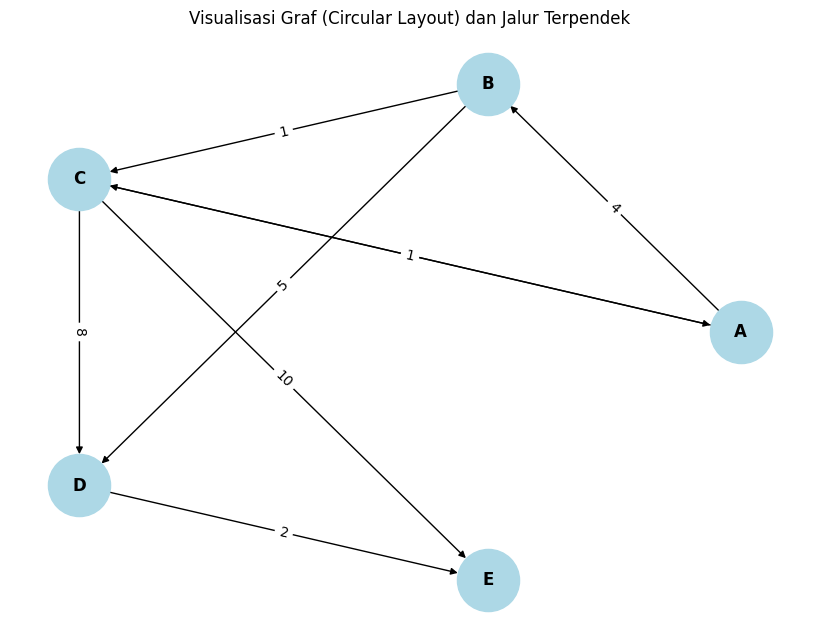

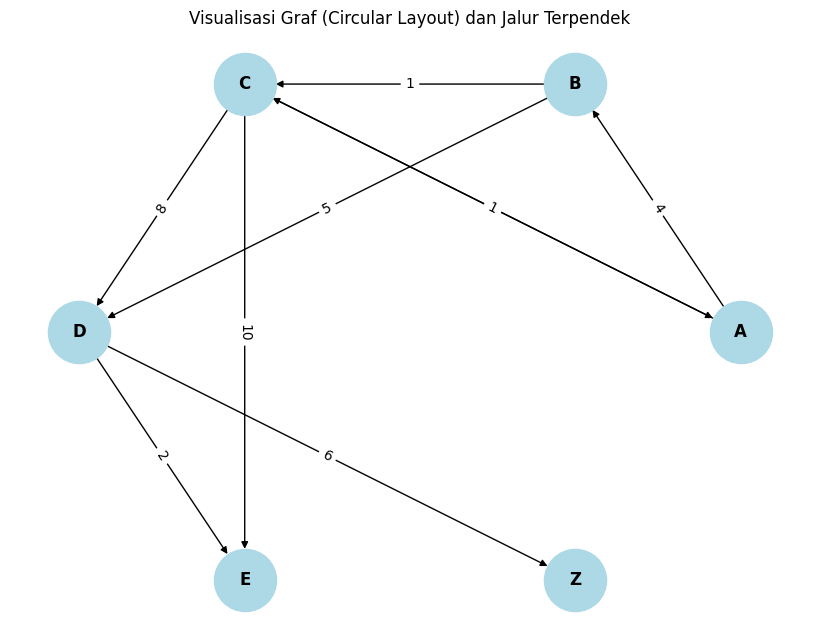

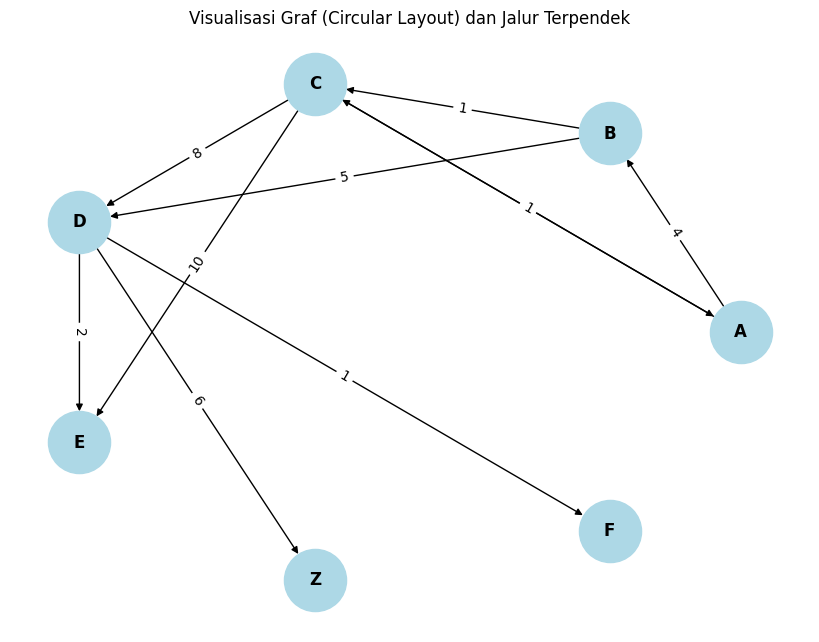

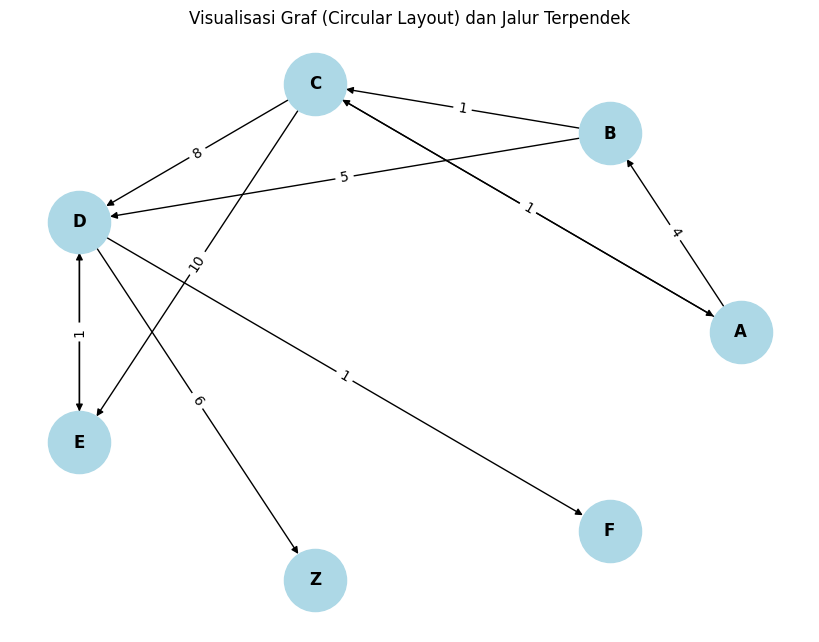

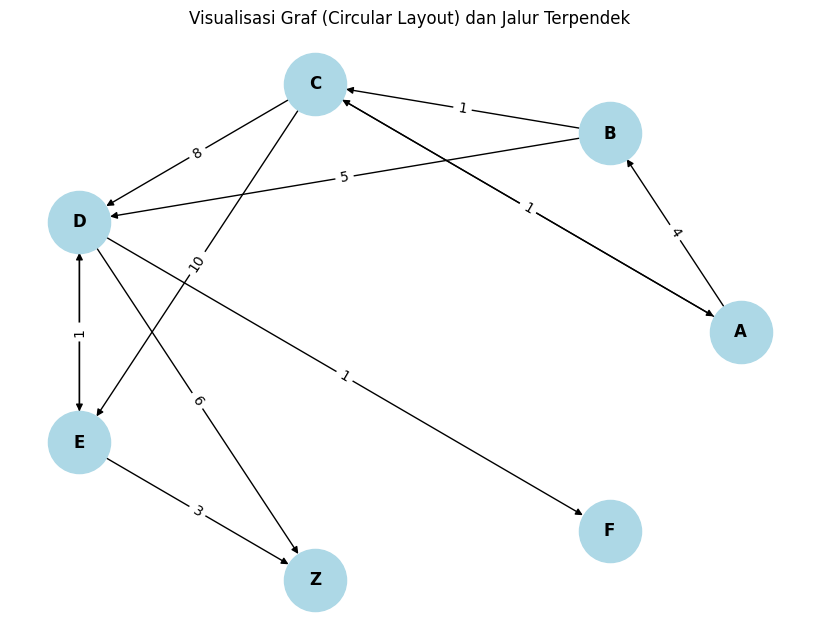

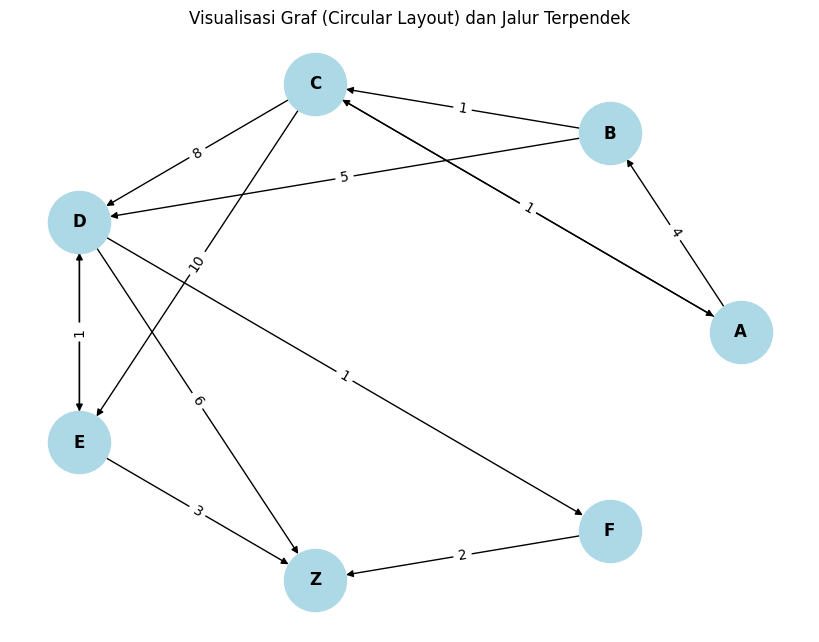

In [8]:
#Definisi graf
graph_modifikasi = {
    'A': {'B':4, 'C':2},
    'B': {'C':1, 'D':5},
    'C': {'A':1, 'D':8, 'E':10},
    'D': {'E':2, 'Z':6, 'F':1},
    'E': {'D':1, 'Z':3},
    'F': {'Z':2},
    'Z': {}
}

start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph_modifikasi, start_node)

shortest_path = get_path(previous, end_node)
print(f'Jarak dari {start_node} ke {end_node}: {distances[end_node]}')
print(f'Jalur: {'->'.join(shortest_path)}')

visualize_graph_circular(graph_modifikasi, path=shortest_path)